In [1]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name(0)}")
print(f"Device Capability: {torch.cuda.get_device_capability(0)}")

CUDA available: True
Device name: NVIDIA GeForce RTX 5070 Ti
Device Capability: (12, 0)


/home/peigao/miniforge3/envs/geneformer/lib/python3.10/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5070 Ti with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [1]:
import scanpy as sc 
adata = sc.read_h5ad('/home/peigao/projects/scRNA_pipeline/data/processed/merged.h5ad')
import sys, os
sys.path.append('/home/peigao/projects/scRNA_pipeline')
from reduction.src.markers import hierarchical_markers

import sys
print(sys.executable)
# adata_aml = adata[adata.obs["category"].isin([1])].copy() ## 1 only RR 0 onlyND
# adata_aml
# adata.obs = adata.obs.rename(columns={"patient": "individual"})

/home/peigao/miniforge3/envs/geneformer/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/peigao/miniforge3/envs/geneformer/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/peigao/miniforge3/envs/geneformer/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/peigao/miniforge3/envs/geneformer/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/peigao/miniforge3/envs/geneformer/lib/python3.10/site-packages/anndata/utils.py:

/home/peigao/miniforge3/envs/geneformer/bin/python


/home/peigao/miniforge3/envs/geneformer/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [2]:
import pandas as pd

# 统计数量
ct = pd.crosstab(
    adata.obs["sample"],
    adata.obs["celltype"]
)

# 转成比例（按行归一化 = 每个 sample 内部）
ct_ratio = ct.div(ct.sum(axis=1), axis=0)

print(ct_ratio)

celltype      B intermediate   B naive  CD8 Naive T cells       GMP        NK  \
sample                                                                          
MR1_0               0.138431  0.147451           0.088824  0.182941  0.112745   
MR1_80              0.122922  0.267060           0.075022  0.015967  0.398294   
MV4_11              0.208645  0.202775           0.125934  0.082177  0.189434   
MV4_TP53fs_2        0.002840  0.005523           0.003629  0.623008  0.004103   

celltype      Plasmablast   Unknown  
sample                               
MR1_0            0.082353  0.247255  
MR1_80           0.078959  0.041776  
MV4_11           0.076841  0.114194  
MV4_TP53fs_2     0.004103  0.356793  


In [3]:
# 新建一个二分类标签
adata.obs["cluster2"] = adata.obs["celltype"].isin(["GMP", "Unknown"])

# 转成更可读标签
adata.obs["cluster2"] = adata.obs["cluster2"].map({
    True: "C2",
    False: "C1"
})

In [4]:
adata.obs["group"] = (
    adata.obs["sample"].astype(str)
    + "_"
    + adata.obs["cluster2"].astype(str)
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

gene = "MCL1"
df = adata.to_df()[[gene]].copy()
df["group"] = adata.obs["group"].values
df = df.reset_index(drop=True)   # 🔥 关键
df.groupby("group")[gene].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
MR1_0_C1,2906.0,0.193055,0.924263,-1.38642,-0.409624,0.254332,0.820781,3.755677
MR1_0_C2,2194.0,-0.916529,1.281452,-1.38642,-1.386420,-1.386420,-1.386420,5.092334
MR1_80_C1,4308.0,0.505025,0.816827,-1.38642,-0.037620,0.542400,1.069240,3.030383
MR1_80_C2,264.0,-0.248673,1.109017,-1.38642,-1.386420,-0.243946,0.452465,4.419333
MV4_11_C1,1506.0,0.632698,0.882761,-1.38642,0.095655,0.679882,1.271413,2.908903
MV4_11_C2,368.0,-0.669385,1.291395,-1.38642,-1.386420,-1.386420,-0.139016,3.967409
MV4_TP53fs_2_C1,128.0,0.203659,1.138992,-1.38642,-0.698016,0.295116,0.993942,2.899823
MV4_TP53fs_2_C2,6209.0,-0.224308,0.634669,-1.38642,-0.650397,-0.238282,0.190304,3.272186


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MV4_11_C2 vs. MV4_11_C1: Mann-Whitney-Wilcoxon test two-sided, P_val:3.180e-44 U_stat=1.481e+05
MV4_TP53fs_2_C2 vs. MV4_TP53fs_2_C1: Mann-Whitney-Wilcoxon test two-sided, P_val:2.883e-11 U_stat=5.337e+05


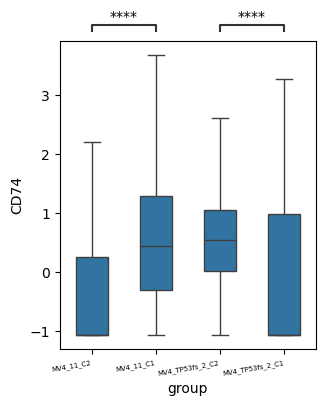

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MV4_11_C2 vs. MV4_TP53fs_2_C2: Mann-Whitney-Wilcoxon test two-sided, P_val:1.379e-61 U_stat=5.566e+05


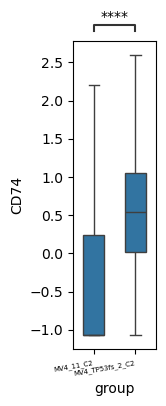

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MV4_11_C1 vs. MV4_TP53fs_2_C1: Mann-Whitney-Wilcoxon test two-sided, P_val:8.977e-09 U_stat=1.258e+05


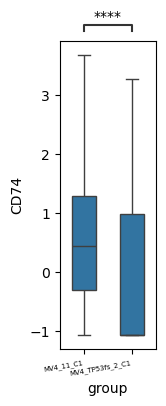

In [10]:

gene = "CD74"
df = adata.to_df()[[gene]].copy()
df["group"] = adata.obs["group"].values
df = df.reset_index(drop=True)   # 🔥 关键
within_sample_pairs = [
    # ✅ within sample（第一层）
    # ('MR1_0_C2', 'MR1_0_C1'),
    # ('MR1_80_C2', 'MR1_80_C1'),
    ('MV4_11_C2', 'MV4_11_C1'),
    ('MV4_TP53fs_2_C2', 'MV4_TP53fs_2_C1'),
]
baseline = 'MV4_11_C2'
GMP_samples = [
    # "MR1_0_C2",
    # "MR1_80_C2",
    "MV4_TP53fs_2_C2"
]
GMP_sample_pairs = [(baseline, x) for x in GMP_samples]

baseline = "MV4_11_C1"
others = [
    # "MR1_0_C1",
    # "MR1_80_C1",
    "MV4_TP53fs_2_C1"
]
others_pairs = [(baseline, x) for x in others]
order = [
    "MV4_11_C2", "MV4_11_C1",
    # "MR1_0_C2", "MR1_0_C1",
    # "MR1_80_C2", "MR1_80_C1",
    "MV4_TP53fs_2_C2", "MV4_TP53fs_2_C1"
]
pairs = [within_sample_pairs, GMP_sample_pairs, others_pairs]
for pair in pairs:
    groups_in_pair = list(set([g for p in pair for g in p]))
    
    sub_order = [g for g in order if g in groups_in_pair]
    plt.figure(figsize=(len(sub_order)*0.8, 4))
    ax = sns.boxplot(
        data=df,
        x="group",
        y=gene,   
        order=sub_order,
        showfliers=False,
        width=0.5   
    )
    annotator = Annotator(
        ax,
        pair,
        data=df,
        x="group",
        order=sub_order,
        y=gene
    )

    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="outside",
        
        line_height=0.02 
    )

    annotator.apply_and_annotate()

    plt.xticks(rotation=10, ha="right", fontsize=5)
    plt.tight_layout(pad=0.5) 
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

gene = "MCL1"
df = adata.to_df()[[gene]].copy()
df["group"] = adata.obs["group8"].values
df = df.reset_index(drop=True)   # 🔥 关键
within_sample_pairs = [
    # ✅ within sample（第一层）
    ('MR1_0_GMP_Unknown', 'MR1_0_Others'),
    ('MR1_80_GMP_Unknown', 'MR1_80_Others'),
    ('MV4_11_GMP_Unknown', 'MV4_11_Others'),
    ('MV4_TP53fs_2_GMP_Unknown', 'MV4_TP53fs_2_Others'),
]
baseline = 'MV4_11_GMP_Unknown'
GMP_samples = [
    "MR1_0_GMP_Unknown",
    "MR1_80_GMP_Unknown",
    "MV4_TP53fs_2_GMP_Unknown"
]
GMP_sample_pairs = [(baseline, x) for x in GMP_samples]

baseline = "MV4_11_Others"
others = [
    "MR1_0_Others",
    "MR1_80_Others",
    "MV4_TP53fs_2_Others"
]
others_pairs = [(baseline, x) for x in others]
order = [
    "MV4_11_GMP_Unknown", "MV4_11_Others",
    "MR1_0_GMP_Unknown", "MR1_0_Others",
    "MR1_80_GMP_Unknown", "MR1_80_Others",
    "MV4_TP53fs_2_GMP_Unknown", "MV4_TP53fs_2_Others"
]
pairs = [within_sample_pairs, GMP_sample_pairs, others_pairs]
for pair in pairs:
    groups_in_pair = list(set([g for p in pair for g in p]))
    
    sub_order = [g for g in order if g in groups_in_pair]
    plt.figure(figsize=(len(sub_order)*0.8, 4))
    ax = sns.boxplot(
        data=df,
        x="group",
        y=gene,   
        order=sub_order,
        showfliers=False,
        width=0.5   
    )
    annotator = Annotator(
        ax,
        pair,
        data=df,
        x="group",
        order=sub_order,
        y=gene
    )

    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="outside",
        
        line_height=0.02 
    )

    annotator.apply_and_annotate()

    plt.xticks(rotation=10, ha="right", fontsize=7)
    plt.tight_layout(pad=0.5) 
    plt.show()

In [39]:
def flatten_markers(hierarchical_markers):
    gene_sets = {}

    for major, content in hierarchical_markers.items():
        # general
        if "general" in content:
            gene_sets[f"{major}_general"] = content["general"]

        # subtypes
        if "subtypes" in content:
            for subtype, genes in content["subtypes"].items():
                gene_sets[f"{subtype}"] = genes

    return gene_sets


gene_sets = flatten_markers(hierarchical_markers)

In [40]:
import scanpy as sc

for name, genes in gene_sets.items():
    genes_use = [g for g in genes if g in adata.var_names]

    if len(genes_use) < 2:
        continue

    sc.tl.score_genes(
        adata,
        gene_list=genes_use,
        score_name=f"{name}_score",
        use_raw=False
    )

In [41]:
score_cols = [f"{k}_score" for k in gene_sets.keys()]

df = adata.obs[["sample", "cluster2"] + score_cols]

In [42]:
summary = df.groupby(["sample", "cluster2"]).mean().reset_index()

/tmp/ipykernel_2009424/529257576.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(["sample", "cluster2"]).mean().reset_index()


In [43]:
pivot = summary.set_index(["sample", "cluster2"])

In [47]:
pivot

CD4_general_score  CD4 Memory T cells_score  \
sample       cluster2                                                   
MR1_0        GMP_Unknown           0.121390                  0.281540   
             Others                0.148007                  0.251782   
MR1_80       GMP_Unknown          -0.111607                 -0.016738   
             Others               -0.198388                 -0.114081   
MV4_11       GMP_Unknown          -0.152876                 -0.031744   
             Others               -0.317722                 -0.281137   
MV4_TP53fs_2 GMP_Unknown           0.120389                 -0.062886   
             Others                0.055985                 -0.224496   

                          CD4 Naive T cells_score  CD4 CTL T cells_score  \
sample       cluster2                                                      
MR1_0        GMP_Unknown                 0.030563               0.022874   
             Others                      0.028436              -0.039275   
MR1_80       GMP_Unknown                 0.076004              -0.064563   
             Others                      0.132077              -0.132358   
MV4_11       GMP_Unknown                 0.286371              -0.013595   
             Others                      0.396998              -0.111611   
MV4_TP53fs_2 GMP_Unknown                -0.227609               0.134048   
             Others                     -0.270615              -0.080071   

                          CD4 Exhausted T cells_score  CD4 Th1 T cells_score  \
sample       cluster2                                                          
MR1_0        GMP_Unknown                    -0.004514               0.008107   
             Others                          0.008436               0.003114   
MR1_80       GMP_Unknown                     0.025837               0.024297   
             Others                          0.012131              -0.010299   
MV4_11       GMP_Unknown                     0.016523               0.005236   
             Others                          0.008612              -0.005236   
MV4_TP53fs_2 GMP_Unknown                    -0.015616               0.003094   
             Others                         -0.006872               0.023779   

                          CD4 Th2 T cells_score  CD4 Th17 T cells_score  \
sample       cluster2                                                     
MR1_0        GMP_Unknown               0.017894                0.002554   
             Others                   -0.076837                0.033067   
MR1_80       GMP_Unknown               0.009272                0.008751   
             Others                   -0.001338                0.078097   
MV4_11       GMP_Unknown               0.000588               -0.071028   
             Others                   -0.062855               -0.129787   
MV4_TP53fs_2 GMP_Unknown               0.042167               -0.038976   
             Others                    0.166088                0.124246   

                          CD4 Tfh T cells_score  Treg_score  ...  \
sample       cluster2                                        ...   
MR1_0        GMP_Unknown              -0.021731   -0.077873  ...   
             Others                   -0.014258   -0.026098  ...   
MR1_80       GMP_Unknown              -0.023197   -0.145523  ...   
             Others                   -0.012872   -0.178045  ...   
MV4_11       GMP_Unknown              -0.014382   -0.121861  ...   
             Others                    0.025701   -0.170727  ...   
MV4_TP53fs_2 GMP_Unknown               0.019283    0.213603  ...   
             Others                    0.027727    0.105404  ...   

                          HSC_general_score  MonocyticLineage_score  \
sample       cluster2                                                 
MR1_0        GMP_Unknown           0.022446                0.135160   
             Others                0.002093               -0.157165   
MR1_80       GMP_

In [48]:
pivot.to_csv("/home/peigao/workspace/scRNA_pipeline/analysis/notebook/biomarker_score_by_group2.csv")

In [49]:
adata_akt3 = adata.copy()
adata_double = adata.copy()

/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [50]:
import numpy as np

def knock_out(adata, gene):
    if gene not in adata.var_names:
        return
    idx = adata.var_names.get_loc(gene)
    adata.X[:, idx] = 0  # 或者设为 very small


# 单KO
knock_out(adata_akt3, "AKT3")

# 双KO
knock_out(adata_double, "AKT3")
knock_out(adata_double, "FLT3")

In [53]:
import anndata as ad
import scanpy as sc

# concat
adata_combined = ad.concat(
    [adata, adata_akt3],
    label="condition",
    keys=["WT", "AKT3_KO"],
    index_unique="-"
)

# 重新 normalize
sc.pp.normalize_total(adata_combined)
sc.pp.log1p(adata_combined)

# DEG
sc.tl.rank_genes_groups(
    adata_combined,
    groupby="condition",
    method="wilcoxon"
)

# concat
adata_combined_double = ad.concat(
    [adata, adata_double],
    label="condition",
    keys=["WT", "Double_KO"],
    index_unique="-"
)

# 重新 normalize
sc.pp.normalize_total(adata_combined_double)
sc.pp.log1p(adata_combined_double)

# DEG
sc.tl.rank_genes_groups(
    adata_combined_double,
    groupby="condition",
    method="wilcoxon"
)

/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/legacy_api_w

In [55]:
adata_combined_double

AnnData object with n_obs × n_vars = 35766 × 38606
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype', 'cluster2', 'CD4_general_score', 'CD4 Memory T cells_score', 'CD4 Naive T cells_score', 'CD4 CTL T cells_score', 'CD4 Exhausted T cells_score', 'CD4 Th1 T cells_score', 'CD4 Th2 T cells_score', 'CD4 Th17 T cells_score', 'CD4 Tfh T cells_score', 'Treg_score', 'CD8_general_score', 'CD8 Naive T cells_score', 'CD8 Effector Memory T cells_score', 'CD8 Exhausted T cells_score', 'CD8 CTL T cells_score', 'MAIT_score', 'B_general_score', 'B intermediate_score', 'B memory_score', 'B naive_score', 'Plasmablast_score', 'pre B_general_score', 'Mono_general_score', 'CD14 Mono_score', 'CD16 Mono_score', 'NK_general_score', 'NK CD56-dim_score', '

In [56]:
adata_sub = adata[adata.obs["celltype"].isin(["Unknown", "GMP"])].copy()

/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
import numpy as np
import scipy.sparse as sp

def get_gene_vector(adata, gene):
    x = adata[:, gene].X
    if sp.issparse(x):
        x = x.toarray()
    return np.ravel(x)

akt3 = get_gene_vector(adata_sub, "AKT3")
flt3 = get_gene_vector(adata_sub, "FLT3")

akt3_q25, akt3_q75 = np.percentile(akt3, [25, 75])
flt3_q25, flt3_q75 = np.percentile(flt3, [25, 75])

adata_sub.obs["AKT3_group"] = "mid"
adata_sub.obs.loc[akt3 <= akt3_q25, "AKT3_group"] = "AKT3_low"
adata_sub.obs.loc[akt3 >= akt3_q75, "AKT3_group"] = "AKT3_high"

adata_sub.obs["FLT3_group"] = "mid"
adata_sub.obs.loc[flt3 <= flt3_q25, "FLT3_group"] = "FLT3_low"
adata_sub.obs.loc[flt3 >= flt3_q75, "FLT3_group"] = "FLT3_high"

import scanpy as sc

adata_fh = adata_sub[
    (adata_sub.obs["FLT3_group"] == "FLT3_high") &
    (adata_sub.obs["AKT3_group"].isin(["AKT3_high", "AKT3_low"]))
].copy()

sc.tl.rank_genes_groups(
    adata_fh,
    groupby="AKT3_group",
    groups=["AKT3_high"],
    reference="AKT3_low",
    method="wilcoxon"
)

adata_fl = adata_sub[
    (adata_sub.obs["FLT3_group"] == "FLT3_low") &
    (adata_sub.obs["AKT3_group"].isin(["AKT3_high", "AKT3_low"]))
].copy()

sc.tl.rank_genes_groups(
    adata_fl,
    groupby="AKT3_group",
    groups=["AKT3_high"],
    reference="AKT3_low",
    method="wilcoxon"
)

deg_fh = sc.get.rank_genes_groups_df(adata_fh, group="AKT3_high")
deg_fl = sc.get.rank_genes_groups_df(adata_fl, group="AKT3_high")

deg_fh_sig = deg_fh[
    (deg_fh["pvals_adj"] < 0.05) &
    (deg_fh["logfoldchanges"].abs() > 1)
].copy()

deg_fl_sig = deg_fl[
    (deg_fl["pvals_adj"] < 0.05) &
    (deg_fl["logfoldchanges"].abs() > 1)
].copy()

genes_fh = set(deg_fh_sig["names"])
genes_fl = set(deg_fl_sig["names"])

shared = genes_fh & genes_fl
fh_only = genes_fh - genes_fl
fl_only = genes_fl - genes_fh

print("shared:", len(shared))
print("FLT3_high only:", len(fh_only))
print("FLT3_low only:", len(fl_only))

compare = deg_fh[["names", "logfoldchanges", "pvals_adj"]].merge(
    deg_fl[["names", "logfoldchanges", "pvals_adj"]],
    on="names",
    how="outer",
    suffixes=("_FH", "_FL")
)

compare = compare.fillna({
    "logfoldchanges_FH": 0,
    "logfoldchanges_FL": 0,
    "pvals_adj_FH": 1,
    "pvals_adj_FL": 1
})

compare["delta_logFC"] = compare["logfoldchanges_FH"] - compare["logfoldchanges_FL"]
compare = compare.sort_values("delta_logFC", ascending=False)

compare.head(20)

In [71]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats

# ================================
# Step 0: 只选你关心的细胞（建议）
# ================================

adata_sub = adata[
    adata.obs["celltype"].isin(["Unknown", "GMP"])
].copy()


# ================================
# Step 1: 基因过滤（去掉dropout噪声）
# ================================

def filter_genes_by_pct_keep(adata, min_pct=0.1, force_keep=None):
    if force_keep is None:
        force_keep = []

    X = adata.X
    if sp.issparse(X):
        detected = np.array((X > 0).sum(axis=0)).flatten()
    else:
        detected = (X > 0).sum(axis=0)

    keep = detected > (min_pct * adata.n_obs)

    # 🔥 强制保留关键基因
    gene_names = np.array(adata.var_names)
    force_mask = np.isin(gene_names, force_keep)

    keep = keep | force_mask

    print(f"Keeping {keep.sum()} / {len(keep)} genes")
    print("Force kept genes:", force_keep)

    return adata[:, keep].copy()
adata_sub = filter_genes_by_pct_keep(adata_sub, min_pct=0.1, force_keep=["AKT3", "FLT3"])


# ================================
# Step 2: pseudobulk（核心）
# ================================

# expression matrix
df_expr = adata_sub.to_df()

# 加 metadata
df_expr["sample"] = adata_sub.obs["sample"].values
df_expr["cluster2"] = adata_sub.obs["cluster2"].values

# pseudobulk（按 sample × cluster）
pb = df_expr.groupby(["sample", "cluster2"]).mean()

print("\nPseudobulk shape:", pb.shape)


# ================================
# Step 3: interaction score
# ================================

# 确保基因存在
assert "AKT3" in pb.columns, "AKT3 not found"
assert "FLT3" in pb.columns, "FLT3 not found"

pb["interaction"] = pb["AKT3"] * pb["FLT3"]


# ================================
# Step 4: 计算 correlation
# ================================

results = []

for gene in pb.columns:
    if gene in ["AKT3", "FLT3", "interaction"]:
        continue

    r, p = stats.spearmanr(pb["interaction"], pb[gene])

    results.append([gene, r, p])

interaction_df = pd.DataFrame(
    results,
    columns=["gene", "interaction_corr", "p"]
)


# ================================
# Step 5: 排序 + 输出
# ================================

interaction_df = interaction_df.sort_values("interaction_corr", ascending=False)

print("\nTop interaction genes:")
print(interaction_df.head(20))


# ================================
# Step 6: 可选：过滤显著基因
# ================================

interaction_sig = interaction_df[
    (interaction_df["p"] < 0.05) &
    (interaction_df["interaction_corr"].abs() > 0.3)
]

print("\nSignificant interaction genes:")
print(interaction_sig.head(20))

/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Keeping 10367 / 38606 genes
Force kept genes: ['AKT3', 'FLT3']


/tmp/ipykernel_2009424/741011601.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pb = df_expr.groupby(["sample", "cluster2"]).mean()



Pseudobulk shape: (4, 10367)

Top interaction genes:
                 gene  interaction_corr    p
4390             MTBP               1.0  0.0
8481             TYMS               1.0  0.0
5795             SIK2               1.0  0.0
8990  ENSG00000266976               1.0  0.0
6252           DEPDC4               1.0  0.0
5224             ADD3               1.0  0.0
4734           ZNF618               1.0  0.0
2844          SLC12A2               1.0  0.0
6249            APAF1               1.0  0.0
4976           PLXDC2               1.0  0.0
4414           CCDC26               1.0  0.0
9697            SYNJ1               1.0  0.0
9469       ZNF337-AS1               1.0  0.0
4941           SFMBT2               1.0  0.0
3575           IPCEF1               1.0  0.0
4141             XKR6               1.0  0.0
2463           PPP3CA               1.0  0.0
2468       UBE2D3-AS1               1.0  0.0
1986          C3orf38               1.0  0.0
4709        LINC01505               1.0  0.0



In [74]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc

# ================================
# Step 0: 基因过滤（非常关键）
# ================================

def filter_genes_by_pct_keep(adata, min_pct=0.1, force_keep=None):
    if force_keep is None:
        force_keep = []

    X = adata.X
    if sp.issparse(X):
        detected = np.array((X > 0).sum(axis=0)).flatten()
    else:
        detected = (X > 0).sum(axis=0)

    keep = detected > (min_pct * adata.n_obs)

    # 🔥 强制保留关键基因
    gene_names = np.array(adata.var_names)
    force_mask = np.isin(gene_names, force_keep)

    keep = keep | force_mask

    print(f"Keeping {keep.sum()} / {len(keep)} genes")
    print("Force kept genes:", force_keep)

    return adata[:, keep].copy()

adata_sub = filter_genes_by_pct_keep(adata_sub, min_pct=0.1, force_keep=["AKT3", "FLT3"])
# ================================
# Step 1: 提取基因表达
# ================================

def get_gene_vector(adata, gene):
    x = adata[:, gene].X
    if sp.issparse(x):
        x = x.toarray()
    return np.ravel(x)

akt3 = get_gene_vector(adata_sub, "AKT3")
flt3 = get_gene_vector(adata_sub, "FLT3")


# ================================
# Step 2: 中位数分组（稳定版）
# ================================

akt3_med = np.median(akt3)
flt3_med = np.median(flt3)

adata_sub.obs["AKT3_group"] = np.where(akt3 >= akt3_med, "AKT3_high", "AKT3_low")
adata_sub.obs["FLT3_group"] = np.where(flt3 >= flt3_med, "FLT3_high", "FLT3_low")
adata_sub.obs["AKT3_group"] = np.where(akt3 > 0, "AKT3_high", "AKT3_low")


print("\nAKT3 group counts:")
print(adata_sub.obs["AKT3_group"].value_counts())

print("\nFLT3 group counts:")
print(adata_sub.obs["FLT3_group"].value_counts())


# ================================
# Step 3: 分 subset
# ================================

adata_fh = adata_sub[adata_sub.obs["FLT3_group"] == "FLT3_high"].copy()
adata_fl = adata_sub[adata_sub.obs["FLT3_group"] == "FLT3_low"].copy()


# ================================
# Step 4: 检查 group size（防假信号）
# ================================

def check_groups(ad, label, min_cells=20):
    counts = ad.obs[label].value_counts()
    print("\nGroup check:")
    print(counts)
    return counts.min() >= min_cells

print("\n=== FLT3_high subset ===")
ok_fh = check_groups(adata_fh, "AKT3_group")

print("\n=== FLT3_low subset ===")
ok_fl = check_groups(adata_fl, "AKT3_group")


# ================================
# Step 5: DEG
# ================================

deg_fh = None
deg_fl = None

if ok_fh:
    sc.tl.rank_genes_groups(
        adata_fh,
        groupby="AKT3_group",
        groups=["AKT3_high"],
        reference="AKT3_low",
        method="wilcoxon"
    )
    deg_fh = sc.get.rank_genes_groups_df(adata_fh, group="AKT3_high")

if ok_fl:
    sc.tl.rank_genes_groups(
        adata_fl,
        groupby="AKT3_group",
        groups=["AKT3_high"],
        reference="AKT3_low",
        method="wilcoxon"
    )
    deg_fl = sc.get.rank_genes_groups_df(adata_fl, group="AKT3_high")


# ================================
# Step 6: 过滤显著基因
# ================================

def filter_deg(df):
    return df[
        (df["pvals_adj"] < 0.05) &
        (df["logfoldchanges"].abs() > 1)
    ].copy()

if deg_fh is not None:
    deg_fh_sig = filter_deg(deg_fh)
else:
    deg_fh_sig = None

if deg_fl is not None:
    deg_fl_sig = filter_deg(deg_fl)
else:
    deg_fl_sig = None


# ================================
# Step 7: overlap
# ================================

if deg_fh_sig is not None and deg_fl_sig is not None:
    genes_fh = set(deg_fh_sig["names"])
    genes_fl = set(deg_fl_sig["names"])

    shared = genes_fh & genes_fl
    fh_only = genes_fh - genes_fl
    fl_only = genes_fl - genes_fh

    print("\n=== DEG overlap ===")
    print("shared:", len(shared))
    print("FLT3_high only:", len(fh_only))
    print("FLT3_low only:", len(fl_only))


# ================================
# Step 8: 构建 compare 表（核心结果）
# ================================

if deg_fh is not None and deg_fl is not None:

    compare = deg_fh[["names", "logfoldchanges", "pvals_adj"]].merge(
        deg_fl[["names", "logfoldchanges", "pvals_adj"]],
        on="names",
        how="outer",
        suffixes=("_FH", "_FL")
    )

    compare = compare.fillna({
        "logfoldchanges_FH": 0,
        "logfoldchanges_FL": 0,
        "pvals_adj_FH": 1,
        "pvals_adj_FL": 1
    })

    compare["delta_logFC"] = compare["logfoldchanges_FH"] - compare["logfoldchanges_FL"]

    compare = compare.sort_values("delta_logFC", ascending=False)

    print("\n=== Top genes (FLT3-dependent direction) ===")
    print(compare.head(20))

Keeping 10367 / 10367 genes
Force kept genes: ['AKT3', 'FLT3']


/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



AKT3 group counts:
AKT3_group
AKT3_low     8165
AKT3_high     870
Name: count, dtype: int64

FLT3 group counts:
FLT3_group
FLT3_high    4518
FLT3_low     4517
Name: count, dtype: int64


/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



=== FLT3_high subset ===

Group check:
AKT3_group
AKT3_low     4017
AKT3_high     501
Name: count, dtype: int64

=== FLT3_low subset ===

Group check:
AKT3_group
AKT3_low     4148
AKT3_high     369
Name: count, dtype: int64

=== DEG overlap ===
shared: 1176
FLT3_high only: 563
FLT3_low only: 1025

=== Top genes (FLT3-dependent direction) ===
                 names  logfoldchanges_FH  pvals_adj_FH  logfoldchanges_FL  \
3387            CFAP69          21.702394           1.0         -20.630556   
9149   ENSG00000253300          22.416256           1.0         -19.818619   
2051          C11orf96          22.390217           1.0         -19.667995   
11513  ENSG00000262714          22.220121           1.0         -19.515604   
12325  ENSG00000267879          22.161694           1.0         -19.440683   
15736  ENSG00000286923          22.243166           1.0         -19.088175   
20770            GRAP2          22.346998           1.0         -18.717867   
36537           TSPAN2         

In [75]:
compare

,names,logfoldchanges_FH,pvals_adj_FH,logfoldchanges_FL,pvals_adj_FL,delta_logFC
3387,CFAP69,21.702394,1.0,-20.630556,1.0,42.332951
9149,ENSG00000253300,22.416256,1.0,-19.818619,1.0,42.234875
2051,C11orf96,22.390217,1.0,-19.667995,1.0,42.058212
11513,ENSG00000262714,22.220121,1.0,-19.515604,1.0,41.735725
12325,ENSG00000267879,22.161694,1.0,-19.440683,1.0,41.602379
...,...,...,...,...,...,...
35631,TMEM212,-17.955084,1.0,22.614159,1.0,-40.569244
18525,ENSG00000290941,-19.156027,1.0,21.423025,1.0,-40.579052
10845,ENSG00000260223,-19.164101,1.0,21.498970,1.0,-40.663071
14722,ENSG00000285661,-18.859442,1.0,22.343220,1.0,-41.202660


In [ ]:
adata.obs["group2"] = adata.obs["celltype"].apply(
    lambda x: "GMP_Unknown" if x in ["GMP", "Unknown"] else "Other"
)

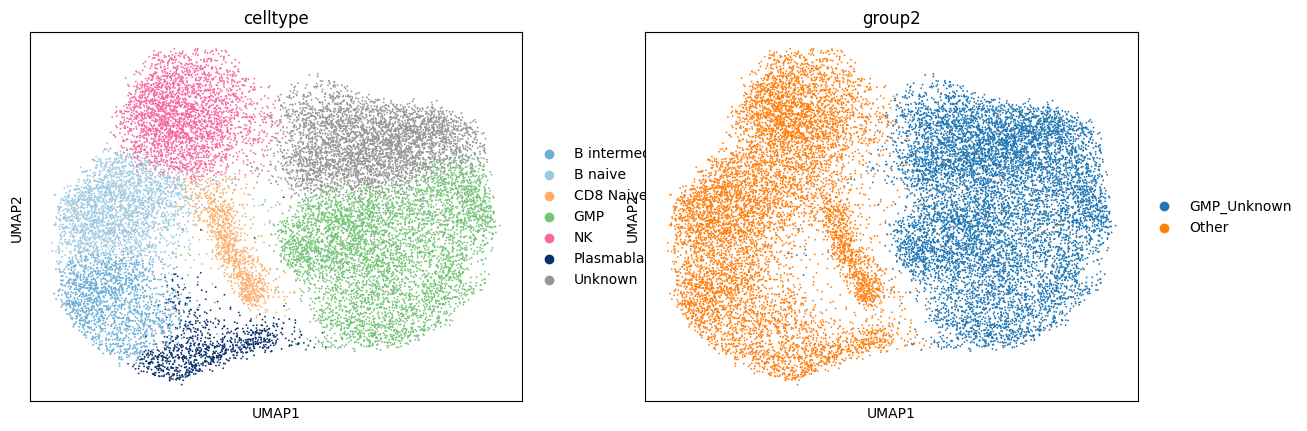

In [6]:
import scanpy as sc

sc.pl.umap(adata, color=["celltype", "group2"])

In [ ]:

import numpy as np

def flatten_markers(hierarchical_markers):
    flat = {}

    for lineage, content in hierarchical_markers.items():
        # general
        if "general" in content:
            flat[f"{lineage}_general"] = content["general"]

        # subtypes
        if "subtypes" in content:
            for subtype, genes in content["subtypes"].items():
                flat[f"{lineage}_{subtype}"] = genes

    return flat


flat_markers = flatten_markers(hierarchical_markers)
scores = {}

for name, genes in flat_markers.items():
    genes_use = [g for g in genes if g in adata.var_names]

    if len(genes_use) == 0:
        continue

    X = adata[:, genes_use].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()

    scores[name] = X.mean(axis=1)

score_df = pd.DataFrame(scores, index=adata.obs_names)

In [28]:
df = pd.concat([
    score_df,
    adata.obs[["group2", "celltype"]]
], axis=1)
result = (
    df
    .groupby(["group2", "celltype"])
    .mean()
    .reset_index()
)
result

/tmp/ipykernel_2009424/262055956.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["group2", "celltype"])


,group2,celltype,CD4_general,CD4_CD4 Memory T cells,CD4_CD4 Naive T cells,CD4_CD4 CTL T cells,CD4_CD4 Exhausted T cells,CD4_CD4 Th1 T cells,CD4_CD4 Th2 T cells,CD4_CD4 Th17 T cells,...,HSC_general,HSC_MonocyticLineage,HSC_Antigen,CLP_general,GMP_general,Macrophage_general,Erythroid_general,Erythroid_Early Erythroid,Erythroid_Late Erythroid,Platelets_general
0,GMP_Unknown,B intermediate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GMP_Unknown,B naive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GMP_Unknown,CD8 Naive T cells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GMP_Unknown,GMP,0.049904,-0.041321,-0.192197,0.090482,-0.031865,-0.008149,-0.017295,-0.095211,...,-0.013922,0.064893,-0.039247,-0.088035,0.163178,-0.011914,-0.012322,0.003697,-0.052115,-0.025219
4,GMP_Unknown,NK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,GMP_Unknown,Plasmablast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,GMP_Unknown,Unknown,0.009286,-0.045854,-0.171422,0.009977,-0.035468,-0.016743,-0.063621,-0.136208,...,-0.015491,0.006088,-0.064138,-0.119792,-0.008192,-0.014224,-0.015209,-0.016940,-0.055221,-0.046899
7,Other,B intermediate,-0.051550,0.036136,0.144519,-0.055409,0.018511,-0.017532,-0.064047,0.063199,...,-0.011213,-0.027288,0.087923,0.118233,-0.126690,-0.017026,-0.010435,-0.016510,0.009734,0.020263
8,Other,B naive,-0.060835,0.043915,0.118538,-0.073600,-0.009555,-0.001394,0.019527,-0.012518,...,-0.010198,-0.089122,0.021706,0.110747,-0.101604,-0.014715,-0.005141,0.004634,0.041630,0.018861
9,Other,CD8 Naive T cells,-0.077145,-0.000325,0.187669,-0.090672,0.033736,-0.005153,0.035317,0.107800,...,-0.007686,-0.048069,-0.013054,-0.011003,-0.072205,-0.011071,-0.002625,-0.023229,0.014199,-0.011459


In [29]:
df = pd.concat([
    score_df,
    adata.obs[["group2"]]
], axis=1)
result = df.groupby("group2").mean().reset_index()
result

/tmp/ipykernel_2009424/3414076684.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby("group2").mean().reset_index()


,group2,CD4_general,CD4_CD4 Memory T cells,CD4_CD4 Naive T cells,CD4_CD4 CTL T cells,CD4_CD4 Exhausted T cells,CD4_CD4 Th1 T cells,CD4_CD4 Th2 T cells,CD4_CD4 Th17 T cells,CD4_CD4 Tfh T cells,...,HSC_general,HSC_MonocyticLineage,HSC_Antigen,CLP_general,GMP_general,Macrophage_general,Erythroid_general,Erythroid_Early Erythroid,Erythroid_Late Erythroid,Platelets_general
0,GMP_Unknown,0.032250,-0.043291,-0.183167,0.055491,-0.033431,-0.011885,-0.037430,-0.113030,-0.018818,...,-0.014604,0.039334,-0.050066,-0.101838,0.088693,-0.012918,-0.013577,-0.005272,-0.053465,-0.034642
1,Other,-0.044403,0.035997,0.162901,-0.069211,0.010458,-0.006767,0.021705,0.098915,-0.010821,...,-0.010772,-0.045029,0.046232,0.090310,-0.098489,-0.011861,-0.007489,-0.012819,0.034902,0.016574


In [30]:
frac_scores = {}

for name, genes in flat_markers.items():
    genes_use = [g for g in genes if g in adata.var_names]
    if len(genes_use) == 0:
        continue

    X = adata[:, genes_use].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()

    frac_scores[name] = (X > 0).mean(axis=1)

frac_df = pd.DataFrame(frac_scores, index=adata.obs_names)

In [31]:
frac_result = (
    pd.concat([frac_df, adata.obs[["group2"]]], axis=1)
    .groupby("group2")
    .mean()
    .reset_index()
)

/tmp/ipykernel_2009424/671145724.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group2")


In [32]:
result_mean = result.set_index("group2")
result_frac = frac_result.set_index("group2")

result_mean.columns = [c + "_mean" for c in result_mean.columns]
result_frac.columns = [c + "_frac" for c in result_frac.columns]

final = pd.concat([result_mean, result_frac], axis=1).reset_index()

In [35]:
final.to_csv("/home/peigao/workspace/scRNA_pipeline/analysis/notebook/biomarker_score_by_group2.csv", index=False)

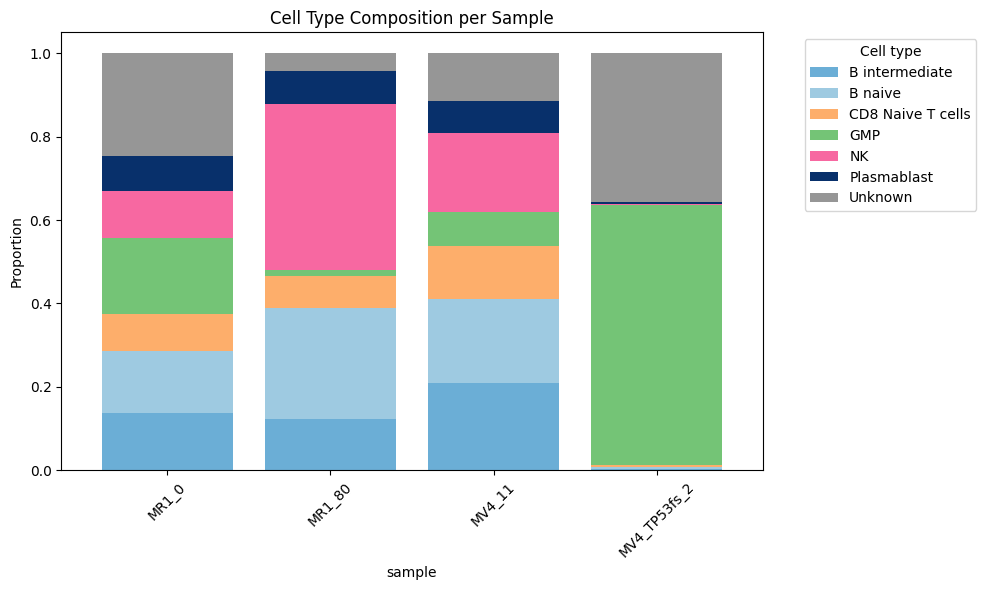

In [8]:
import matplotlib.pyplot as plt
from my_pipeline.src.annotation import celltype_colors_dict 
# ===== 数据 =====
df = ct_ratio.copy().fillna(0)

# 🔥 保证顺序和 adata 一致（非常关键）
celltypes = adata.obs["celltype"].cat.categories

# 只保留存在的列（防止有缺失）
celltypes = [ct for ct in celltypes if ct in df.columns]
df = df[celltypes]

# ===== 颜色映射 =====
colors = [
    celltype_colors_dict.get(ct, "#999999")
    for ct in celltypes
]

# ===== 画图 =====
fig, ax = plt.subplots(figsize=(10, 6))

df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.8
)

# ===== 美化 =====
ax.set_ylabel("Proportion")
ax.set_title("Cell Type Composition per Sample")
ax.set_xticklabels(df.index, rotation=45)

# 图例放右边
ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()